---
title: Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego
jupyter:
  jupytext:
    main_language: python
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.17.3
  kernelspec:
    display_name: Python 3
    language: python
    name: python3
---



## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:


## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [20]:
df1 = pd.read_csv("./student_lifestyle_performance_dataset.csv")

df1.sort_values(by="CGPA", ascending=False)[["Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week"]].head(15)

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week
657,22,6.85,8.45,3.84,12.67
109,23,5.83,9.26,7.19,6.05
843,24,4.64,8.34,3.28,3.59
405,17,6.87,7.92,2.21,18.13
464,25,5.18,9.13,7.92,7.85
171,20,8.05,7.34,6.46,0.00
475,19,5.71,8.07,2.98,12.96
639,19,7.30,8.57,3.96,8.24
659,20,3.85,9.22,7.14,5.21
682,25,4.87,8.25,4.95,0.00


## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [31]:
df2 = pd.read_csv("./student_lifestyle_performance_dataset.csv")

df2["Free_Hours_per_Day"] = 24 - ((df2["Gym_Hours_per_Week"] / 7 + 2.5 + df2["Screen_Time_Hours"] + df2["Study_Hours_per_Day"] - 1 + df2["Sleep_Hours"]))
df2[["Free_Hours_per_Day", "Gym_Hours_per_Week", "Screen_Time_Hours", "Study_Hours_per_Day", "Sleep_Hours"]].round(2).head()

,Free_Hours_per_Day,Taken_Hours_per_Day,Gym_Hours_per_Day,Eating_Hygiene_Hourse_per_Day,Screen_Studying_Time
0,1.91,22.09,0.38,2.5,1
1,5.69,18.31,2.23,2.5,1
2,10.54,13.46,0.36,2.5,1
3,2.08,21.92,0.00,2.5,1
4,4.36,19.64,1.42,2.5,1


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [92]:
df3 = pd.read_csv("./student_lifestyle_performance_dataset.csv")

it_mechanical_mask = df3["Branch"].isin(["IT", "Mechanical"])
df3 = df3[df3["Age"] >= 18]

df3["Mean_Branch_Stress_Level"] = df3.groupby("Branch")["Stress_Level_1_to_10"].transform("mean")
df3["Median_Sleep_Hours"] = df3.groupby("Branch")["Sleep_Hours"].transform("median")

df3[["Branch", "Mean_Branch_Stress_Level", "Median_Sleep_Hours"]].drop_duplicates().sort_values(by="Mean_Branch_Stress_Level", ascending=False)

,Branch,Mean_Branch_Stress_Level,Median_Sleep_Hours
1,Civil,4.630494,6.710
0,ECE,4.626014,6.405
8,Mechanical,4.608940,6.640
2,Electrical,4.544621,6.310
3,CSE,4.526667,6.540
9,IT,4.454929,6.755


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

In [ ]:
df4 = pd.read_csv("./student_lifestyle_performance_dataset.csv")

for diet_type in df4["Diet_Type"].unique():
  gpa = df4[df4["Diet_Type"] == diet_type]["CGPA"]
  sleep_time = df4[df4["Diet_Type"] == diet_type]["Sleep_Hours"]
  plt.scatter(gpa, sleep_time, label=diet_type)

plt.legend()
plt.title("Zależność między średnią a czasem snu (z podziałem na dietę)")
plt.xlabel("Średnia")
plt.ylabel("Czas snu")
plt.show()

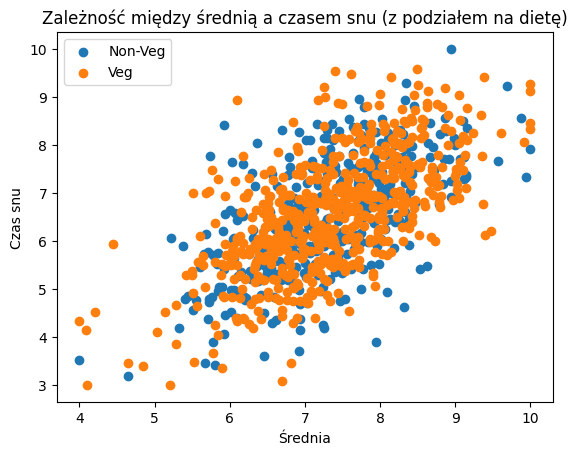

<Axes: title={'center': 'Średnia obecność na zajęciach poszczególnych dziedzin nauki'}, xlabel='Dziedzina', ylabel='Średnia Obecność'>

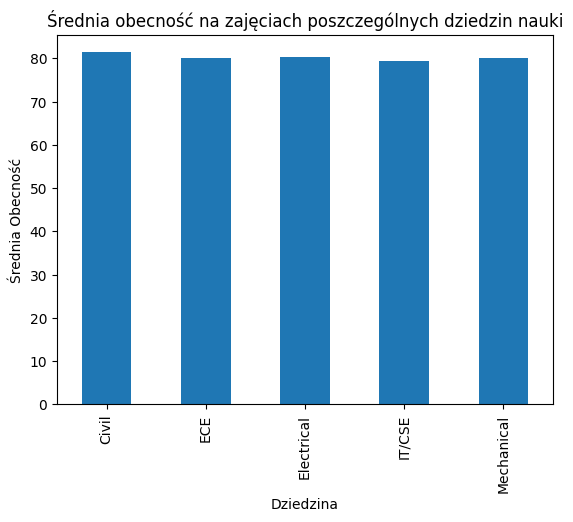

In [125]:
df4.groupby(df4["Branch"].replace({"IT": "IT/CSE", "CSE": "IT/CSE"}))["Attendance_Percentage"] \
  .mean() \
  .plot(kind="bar", title="Średnia obecność na zajęciach poszczególnych dziedzin nauki", ylabel="Średnia Obecność", xlabel="Dziedzina")

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w postach na poszczególnych platformach?

In [ ]:
df5 = pd.read_csv("./social_media_viral_content_dataset.csv")
df5["post_datetime"] = pd.to_datetime(df5["post_datetime"])

df5[(df5["platform"] == "YouTube Shorts") & (df5["post_datetime"] >= "2024-10-01") & (df5["post_datetime"] <= "2024-12-31")] \
    .groupby("topic")["topic"] \
    .count() \
    .plot(kind="bar", title="Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024")

In [ ]:
df5_hashtags = df5[["views", "hashtags", "platform"]].copy()
df5_hashtags["hashtags"] = df5["hashtags"].str.split(" ")
df5_hashtags_exp = df5_hashtags.explode(column="hashtags")
df5_hashtags_exp.groupby(["platform", "hashtags"])["views"] \
    .mean() \
    .unstack() \
    .plot(kind="bar", title="Najbardziej opłacalne hashtagi na danych platformach", xlabel="platforma", ylabel="Średnia liczba wyświetleń", legend='reverse')